# Data Exploration
Exploratory analysis of the four raw datasets:
- `posek.csv` — ZGS logging records
- `vreme.csv` — ARSO weather station records
- `odseki_gozdno.gpkg` — forest sections (spatial)
- `sestoji.gpkg` — forest stands (spatial)

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 30)

ROOT = Path('..').resolve()
RAW  = ROOT / 'data' / 'raw'

---
## 1. posek.csv — Logging Records

In [2]:
posek = pd.read_csv(RAW / 'ZGS' / 'posek.csv')
posek.columns = posek.columns.str.strip()
posek['odsek'] = posek['odsek'].str.strip()
posek['posekano'] = pd.to_datetime(posek['posekano'], errors='coerce')

print(f'Shape: {posek.shape}')
posek.head()

Shape: (450064, 8)


/tmp/ipykernel_71531/2970654808.py:1: DtypeWarning: Columns (0: manual) have mixed types. Specify dtype option on import or set low_memory=False.
  posek = pd.read_csv(RAW / 'ZGS' / 'posek.csv')


,ggo,odsek,manual,kubikov,vrsec,posekano,ko,parcela
0,1,01026A,7001,22.73,301,2007-01-01,2204,1
1,1,01064B,7001,20.18,301,2007-02-01,2210,1
2,1,01064B,7002,7.56,301,2007-03-01,2210,1
3,1,01076A,7001,8.61,301,2007-01-01,2210,1
4,1,01076A,7002,13.62,301,2007-01-01,2210,1


In [3]:
posek.dtypes

ggo                  int64
odsek                  str
manual              object
kubikov            float64
vrsec                int64
posekano    datetime64[us]
ko                   int64
parcela                str
dtype: object

In [4]:
posek.describe()

,ggo,kubikov,vrsec,posekano,ko
count,450064.00000,450064.000000,450064.000000,450064,450064.000000
mean,5.89086,31.630142,482.555779,2017-11-10 03:20:37.456006,1653.348808
min,1.00000,0.000000,301.000000,2007-01-01 00:00:00,1.000000
25%,3.00000,4.827500,301.000000,2014-12-19 00:00:00,1115.000000
50%,5.00000,12.740000,301.000000,2017-09-01 00:00:00,1778.000000
75%,9.00000,31.880000,901.000000,2022-08-17 00:00:00,2112.000000
max,14.00000,2936.590000,991.000000,2025-12-31 00:00:00,2714.000000
std,3.41049,69.150405,280.345986,NaN,564.686752


In [5]:
print('Missing values:')
posek.isnull().sum()

Missing values:


ggo           0
odsek         0
manual        0
kubikov       0
vrsec         0
posekano      0
ko            0
parcela     108
dtype: int64

In [6]:
print(f'Date range: {posek["posekano"].min()} → {posek["posekano"].max()}')
print(f'Unique odsek: {posek["odsek"].nunique():,}')
print(f'Unique GGO:   {posek["ggo"].nunique()}')
print(f'Unique vrsec: {posek["vrsec"].nunique()} → {sorted(posek["vrsec"].unique())}')

Date range: 2007-01-01 00:00:00 → 2025-12-31 00:00:00
Unique odsek: 25,691
Unique GGO:   14
Unique vrsec: 3 → [np.int64(301), np.int64(901), np.int64(991)]


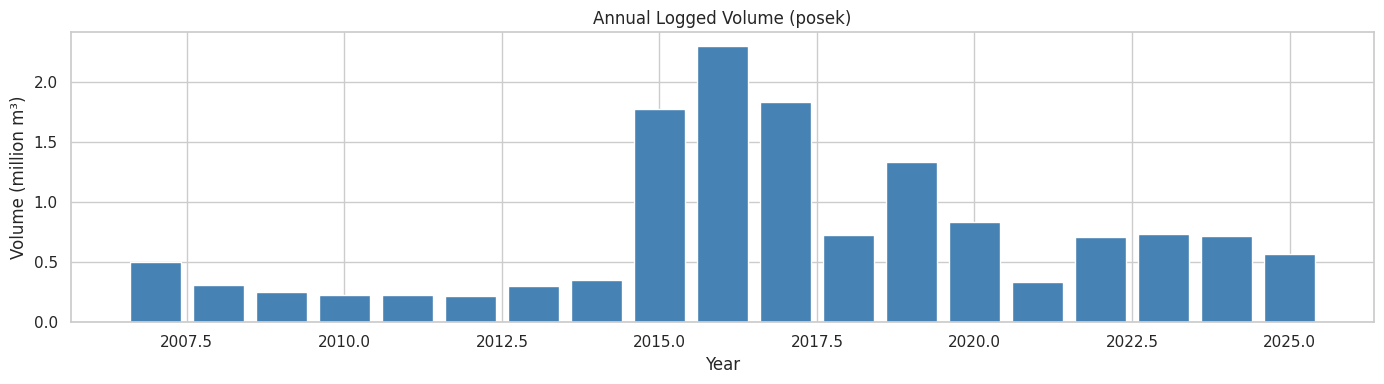

In [7]:
# Annual logged volume
posek['leto'] = posek['posekano'].dt.year
annual = posek.groupby('leto')['kubikov'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(annual['leto'], annual['kubikov'] / 1e6, color='steelblue')
ax.set_xlabel('Year')
ax.set_ylabel('Volume (million m³)')
ax.set_title('Annual Logged Volume (posek)')
plt.tight_layout()
plt.show()

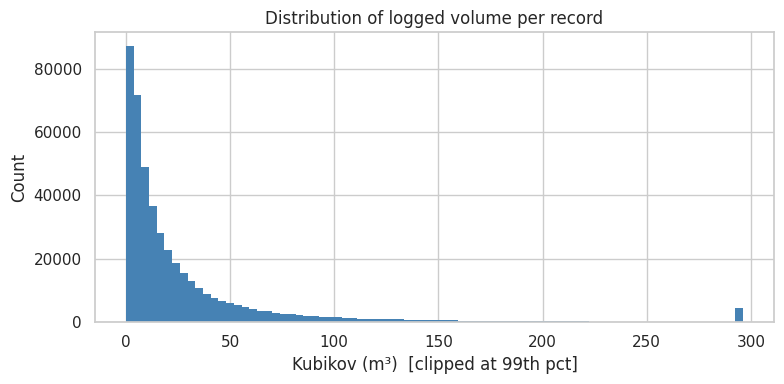

In [8]:
# Distribution of kubikov (log scale)
fig, ax = plt.subplots(figsize=(8, 4))
posek['kubikov'].clip(upper=posek['kubikov'].quantile(0.99)).hist(bins=80, ax=ax, color='steelblue', edgecolor='none')
ax.set_xlabel('Kubikov (m³)  [clipped at 99th pct]')
ax.set_ylabel('Count')
ax.set_title('Distribution of logged volume per record')
plt.tight_layout()
plt.show()

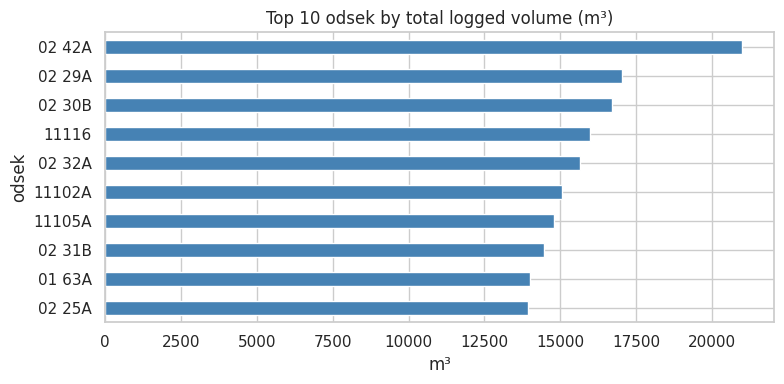

In [9]:
# Top 10 odsek by total volume
posek.groupby('odsek')['kubikov'].sum().nlargest(10).sort_values().plot(
    kind='barh', figsize=(8, 4), color='steelblue', title='Top 10 odsek by total logged volume (m³)'
)
plt.xlabel('m³')
plt.tight_layout()
plt.show()

---
## 2. vreme.csv — Weather Records

In [10]:
vreme = pd.read_csv(
    RAW / 'ARSO' / 'vreme.csv',
    encoding='utf-8',
    low_memory=False,
)
# Fix double-encoded column names → clean Slovenian labels
vreme.columns = [
    'station_id', 'datum',
    'temp_avg_C', 'temp_max_C', 'temp_min_C',
    'padavine_mm', 'snezna_odeja_cm', 'novi_sneg_cm',
    'nevihta', 'toca', 'viharni_veter',
]
vreme['datum'] = pd.to_datetime(vreme['datum'], errors='coerce')

print(f'Shape: {vreme.shape}')
vreme.head()

Shape: (1556514, 11)


,station_id,datum,temp_avg_C,temp_max_C,temp_min_C,padavine_mm,snezna_odeja_cm,novi_sneg_cm,nevihta,toca,viharni_veter
0,43,1800-01-01,NaN,NaN,NaN,20.8,0.0,0.0,ne,ne,ne
1,43,1800-01-01,NaN,NaN,NaN,0.0,0.0,0.0,ne,ne,ne
2,43,1800-01-01,NaN,NaN,NaN,13.1,0.0,0.0,ne,ne,ne
3,43,1800-01-01,NaN,NaN,NaN,0.0,0.0,0.0,ne,ne,ne
4,43,1800-01-01,NaN,NaN,NaN,0.0,0.0,0.0,ne,ne,ne


In [11]:
vreme.dtypes

station_id                  int64
datum              datetime64[us]
temp_avg_C                float64
temp_max_C                float64
temp_min_C                float64
padavine_mm               float64
snezna_odeja_cm           float64
novi_sneg_cm              float64
nevihta                       str
toca                          str
viharni_veter                 str
dtype: object

In [12]:
vreme.describe()

,station_id,datum,temp_avg_C,temp_max_C,temp_min_C,padavine_mm,snezna_odeja_cm,novi_sneg_cm
count,1.556514e+06,1556514,304007.000000,304071.000000,304078.000000,1.556236e+06,1.550603e+06,1.550572e+06
mean,1.930625e+03,2013-06-23 22:33:30.828813,9.873855,15.193011,5.355836,3.987349e+00,3.240811e+00,3.031172e-01
min,4.300000e+01,1800-01-01 00:00:00,-25.700000,-22.900000,-30.600000,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.681000e+03,2007-08-15 00:00:00,3.400000,7.900000,-0.400000,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.754000e+03,2014-01-19 00:00:00,10.000000,15.300000,5.700000,0.000000e+00,0.000000e+00,0.000000e+00
75%,1.896000e+03,2019-12-16 00:00:00,16.600000,23.000000,11.500000,2.100000e+00,0.000000e+00,0.000000e+00
max,4.794000e+03,2026-03-20 00:00:00,32.300000,40.600000,26.300000,3.534000e+02,7.000000e+02,1.300000e+02
std,5.468605e+02,NaN,8.452944,9.652668,7.719356,1.059305e+01,1.969917e+01,2.271568e+00


In [13]:
print('Missing values (%):')
(vreme.isnull().sum() / len(vreme) * 100).round(1)

Missing values (%):


station_id          0.0
datum               0.0
temp_avg_C         80.5
temp_max_C         80.5
temp_min_C         80.5
padavine_mm         0.0
snezna_odeja_cm     0.4
novi_sneg_cm        0.4
nevihta             0.0
toca                0.6
viharni_veter       0.6
dtype: float64

In [14]:
print(f'Date range:      {vreme["datum"].min()} → {vreme["datum"].max()}')
print(f'Unique stations: {vreme["station_id"].nunique()}')
print(f'Station IDs:     {sorted(vreme["station_id"].unique())}')

Date range:      1800-01-01 00:00:00 → 2026-03-20 00:00:00
Unique stations: 217
Station IDs:     [np.int64(43), np.int64(286), np.int64(381), np.int64(1611), np.int64(1612), np.int64(1613), np.int64(1614), np.int64(1622), np.int64(1624), np.int64(1625), np.int64(1626), np.int64(1627), np.int64(1628), np.int64(1635), np.int64(1636), np.int64(1637), np.int64(1639), np.int64(1641), np.int64(1642), np.int64(1644), np.int64(1648), np.int64(1649), np.int64(1650), np.int64(1651), np.int64(1652), np.int64(1653), np.int64(1654), np.int64(1655), np.int64(1656), np.int64(1657), np.int64(1659), np.int64(1661), np.int64(1662), np.int64(1663), np.int64(1664), np.int64(1665), np.int64(1668), np.int64(1669), np.int64(1670), np.int64(1672), np.int64(1673), np.int64(1674), np.int64(1675), np.int64(1677), np.int64(1678), np.int64(1679), np.int64(1681), np.int64(1683), np.int64(1686), np.int64(1688), np.int64(1689), np.int64(1690), np.int64(1691), np.int64(1694), np.int64(1695), np.int64(1698), np.int64(1

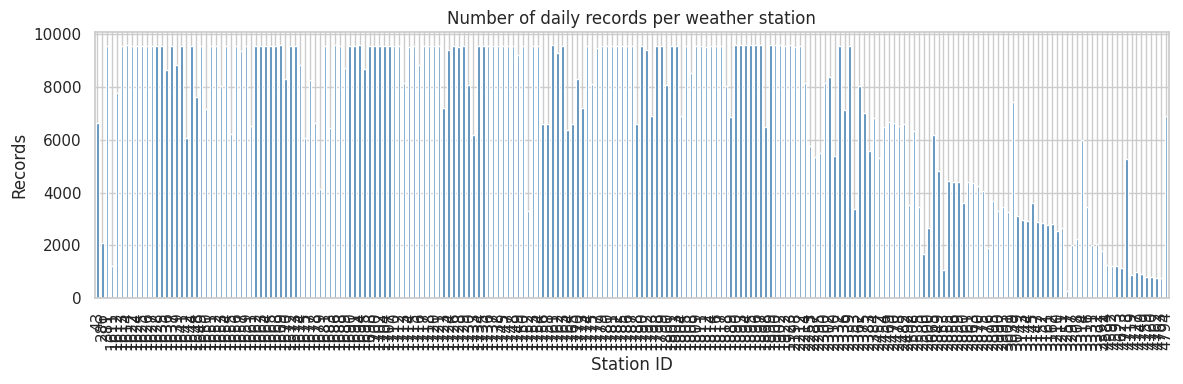

In [15]:
# Records per station
vreme['station_id'].value_counts().sort_index().plot(
    kind='bar', figsize=(12, 4), color='steelblue',
    title='Number of daily records per weather station'
)
plt.xlabel('Station ID')
plt.ylabel('Records')
plt.tight_layout()
plt.show()

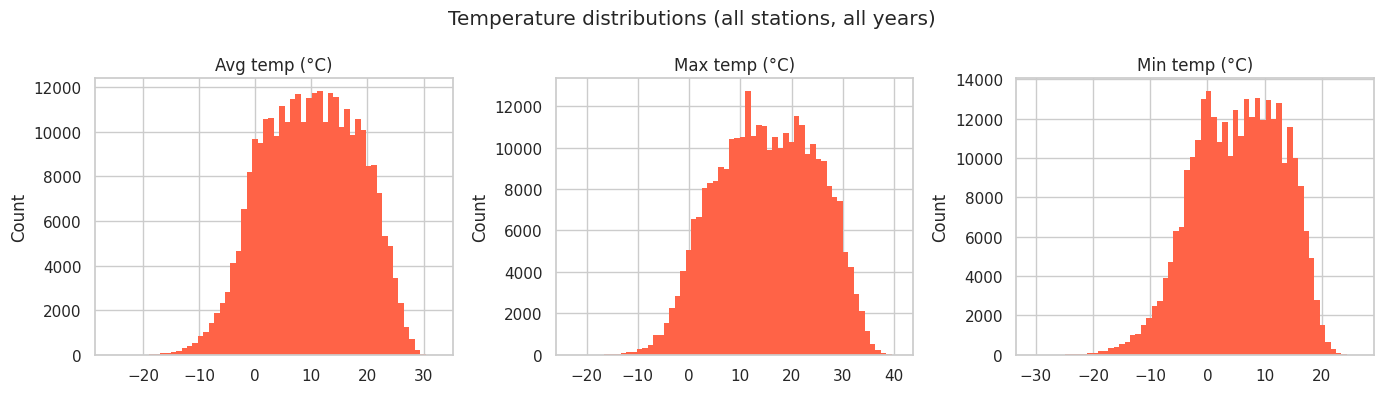

In [16]:
# Temperature distributions
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, col, label in zip(axes,
    ['temp_avg_C', 'temp_max_C', 'temp_min_C'],
    ['Avg temp (°C)', 'Max temp (°C)', 'Min temp (°C)']):
    vreme[col].dropna().hist(bins=60, ax=ax, color='tomato', edgecolor='none')
    ax.set_title(label)
    ax.set_ylabel('Count')
plt.suptitle('Temperature distributions (all stations, all years)')
plt.tight_layout()
plt.show()

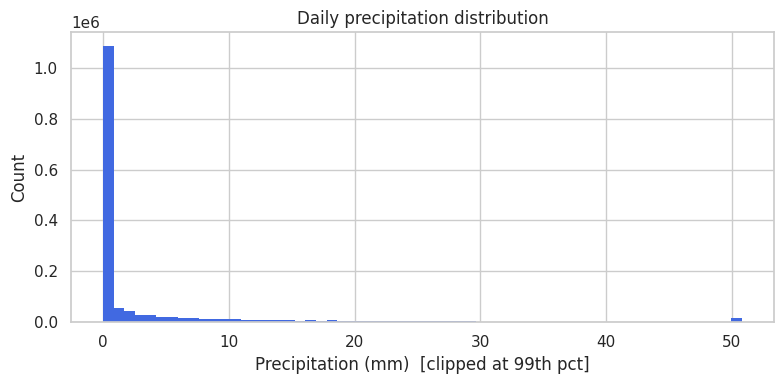

In [17]:
# Precipitation distribution (clipped)
fig, ax = plt.subplots(figsize=(8, 4))
vreme['padavine_mm'].clip(upper=vreme['padavine_mm'].quantile(0.99)).dropna().hist(
    bins=60, ax=ax, color='royalblue', edgecolor='none'
)
ax.set_xlabel('Precipitation (mm)  [clipped at 99th pct]')
ax.set_ylabel('Count')
ax.set_title('Daily precipitation distribution')
plt.tight_layout()
plt.show()

/tmp/ipykernel_71531/68419776.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


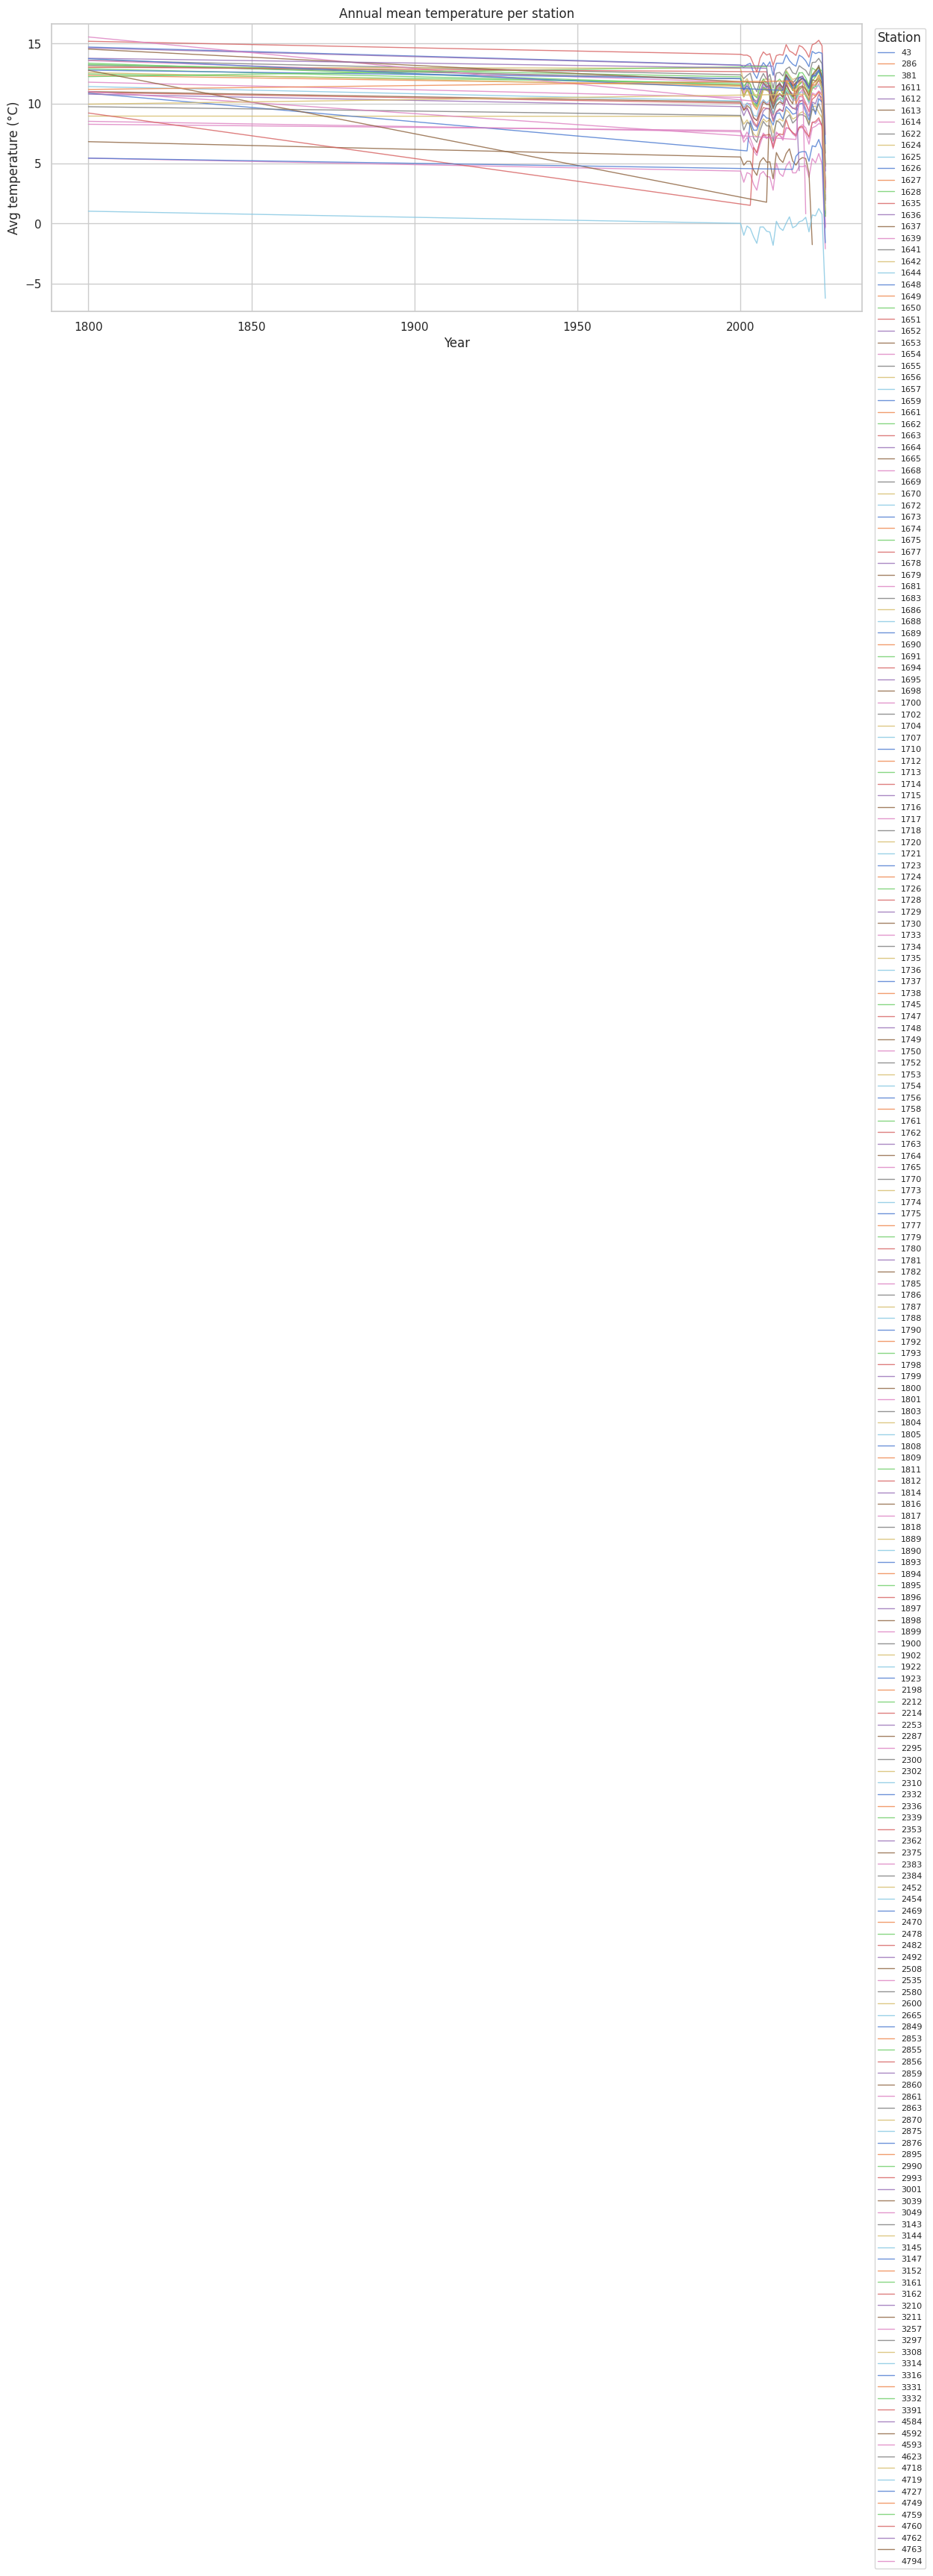

In [18]:
# Annual average temperature per station
vreme['leto'] = vreme['datum'].dt.year
annual_temp = vreme.groupby(['leto', 'station_id'])['temp_avg_C'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
for sid, grp in annual_temp.groupby('station_id'):
    ax.plot(grp['leto'], grp['temp_avg_C'], marker='', linewidth=1, label=str(sid), alpha=0.8)
ax.set_xlabel('Year')
ax.set_ylabel('Avg temperature (°C)')
ax.set_title('Annual mean temperature per station')
ax.legend(title='Station', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

---
## 3. odseki_gozdno.gpkg — Forest Sections

In [19]:
odseki = gpd.read_file(RAW / 'ZGS' / 'odseki_gozdno.gpkg')

print(f'Shape:   {odseki.shape}')
print(f'CRS:     {odseki.crs}')
print(f'GGO units: {odseki["ggo"].nunique()}')
odseki.drop(columns='geometry').head()

Shape:   (53254, 56)
CRS:     EPSG:3794
GGO units: 14


,ggo,ggo_naziv,odsek,povrsina,gge,gge_naziv,ke,ke_naziv,revir,revir_naziv,rgr_ggo,rgr_ggo_naziv,rgr_gge,rgr_gge_naziv,katgozd,...,spravilo_naziv,razdalja,odprtost,odprt_gurs,pozar,pozar_naziv,intgosp,intgosp_naziv,krajime,grt1,grt1_naziv,rk,rk_gurs,carb_tot_t,ponor_c
0,09,CELJE,31001,16.57,31,VRANSKO,21,Žalec,2114,Tabor,00081,Zasmrečena gorska in zgornjegorska bukovja na ...,3,MONTANSKA IN ALTIMONTANSKA BUKOVJA IN JELOVO B...,1,...,S TRAKTORJEM,150,80,80.0,3,SREDNJA OGROŽENOST,4,VELIKA INTENZIVNOST,Prvine,632,Predalpsko gorsko bukovje ...,9,9,162.5,10.9
1,09,CELJE,31002,31.37,31,VRANSKO,21,Žalec,2114,Tabor,00061,Zasmrečena podgorska bukovja na silikatnih kam...,3,MONTANSKA IN ALTIMONTANSKA BUKOVJA IN JELOVO B...,1,...,S TRAKTORJEM,150,100,100.0,3,SREDNJA OGROŽENOST,4,VELIKA INTENZIVNOST,Prvine,632,Predalpsko gorsko bukovje ...,9,9,153.5,5.1
2,09,CELJE,31003,20.00,31,VRANSKO,21,Žalec,2114,Tabor,00070,Gorska in zgornjegorska bukovja na silikatnih ...,3,MONTANSKA IN ALTIMONTANSKA BUKOVJA IN JELOVO B...,1,...,S TRAKTORJEM,150,100,100.0,3,SREDNJA OGROŽENOST,4,VELIKA INTENZIVNOST,Jelenov rog,632,Predalpsko gorsko bukovje ...,9,7,181.5,6.7
3,09,CELJE,31004,23.42,31,VRANSKO,21,Žalec,2114,Tabor,00070,Gorska in zgornjegorska bukovja na silikatnih ...,3,MONTANSKA IN ALTIMONTANSKA BUKOVJA IN JELOVO B...,1,...,S TRAKTORJEM,100,100,100.0,3,SREDNJA OGROŽENOST,4,VELIKA INTENZIVNOST,KORENA,632,Predalpsko gorsko bukovje ...,9,7,163.0,7.3
4,09,CELJE,31005,18.53,31,VRANSKO,21,Žalec,2114,Tabor,00070,Gorska in zgornjegorska bukovja na silikatnih ...,3,MONTANSKA IN ALTIMONTANSKA BUKOVJA IN JELOVO B...,1,...,S TRAKTORJEM,250,90,90.0,3,SREDNJA OGROŽENOST,4,VELIKA INTENZIVNOST,NaN,681,Preddinarsko zgornjegorsko bukovje z zasavsko ...,7,7,212.1,4.1


In [36]:
sestoji.columns

Index(['ggo', 'ggo_naziv', 'odsek', 'sestoj', 'povrsina', 'rfaza',
       'rfaza_naziv', 'lzskdv11', 'lzskdv11_m', 'lzskdv21', 'lzskdv21_m',
       'lzskdv30', 'lzskdv30_m', 'lzskdv34', 'lzskdv34_m', 'lzskdv39',
       'lzskdv39_m', 'lzskdv41', 'lzskdv41_m', 'lzskdv50', 'lzskdv50_m',
       'lzskdv60', 'lzskdv60_m', 'lzskdv70', 'lzskdv70_m', 'lzskdv80',
       'lzskdv80_m', 'sksmerni', 'sksmerni_naziv', 'zasnova', 'zasnova_naziv',
       'sklep', 'sklep_naziv', 'negovan', 'negovanost_naziv', 'pompov',
       'pomzas', 'pomzas_naziv', 'lzigl', 'lzlst', 'lzsku', 'etigl', 'etlst',
       'etsku', 'geometry', 'del_iglavcev'],
      dtype='str')

In [20]:
odseki.drop(columns='geometry').describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ggo,53254,14,12,7707,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ggo_naziv,53254,14,MARIBOR,7707,NaN,NaN,NaN,NaN,NaN,NaN,NaN
odsek,53254,35688,05013A,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
povrsina,53254.0,NaN,NaN,NaN,22.11019,20.359103,0.0,8.56,17.44,29.85,314.42
gge,53254,69,07,3328,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gge_naziv,53254,226,ŠENTILJ V SL. GOR.,627,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ke,53254,14,23,9810,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ke_naziv,53254,69,Maribor,1687,NaN,NaN,NaN,NaN,NaN,NaN,NaN
revir,53254,215,2103,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
revir_naziv,53254,389,Planina,505,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
print('Missing values (%):')
(odseki.drop(columns='geometry').isnull().sum() / len(odseki) * 100).round(1)[lambda s: s > 0]

Missing values (%):


krajime    11.7
dtype: float64

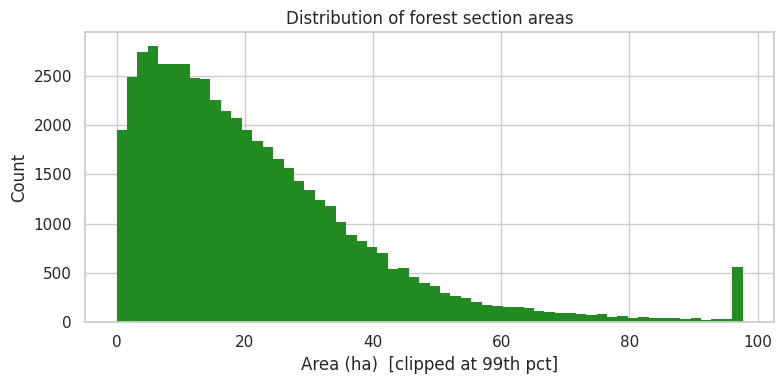

In [22]:
# Area distribution per section
fig, ax = plt.subplots(figsize=(8, 4))
odseki['povrsina'].clip(upper=odseki['povrsina'].quantile(0.99)).hist(
    bins=60, ax=ax, color='forestgreen', edgecolor='none'
)
ax.set_xlabel('Area (ha)  [clipped at 99th pct]')
ax.set_ylabel('Count')
ax.set_title('Distribution of forest section areas')
plt.tight_layout()
plt.show()

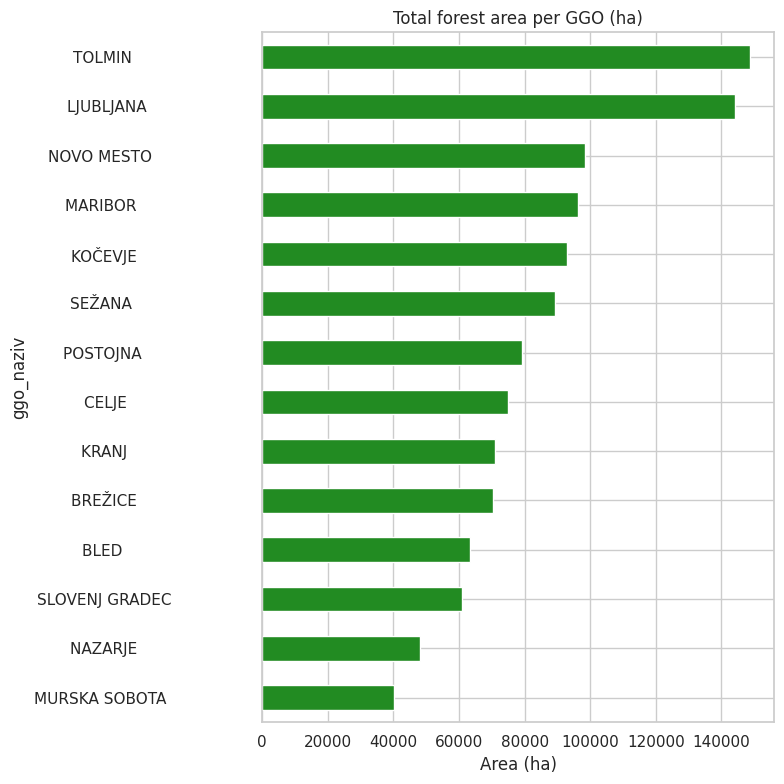

In [23]:
# Total area per GGO
odseki.groupby('ggo_naziv')['povrsina'].sum().sort_values(ascending=True).plot(
    kind='barh', figsize=(8, 8), color='forestgreen',
    title='Total forest area per GGO (ha)'
)
plt.xlabel('Area (ha)')
plt.tight_layout()
plt.show()

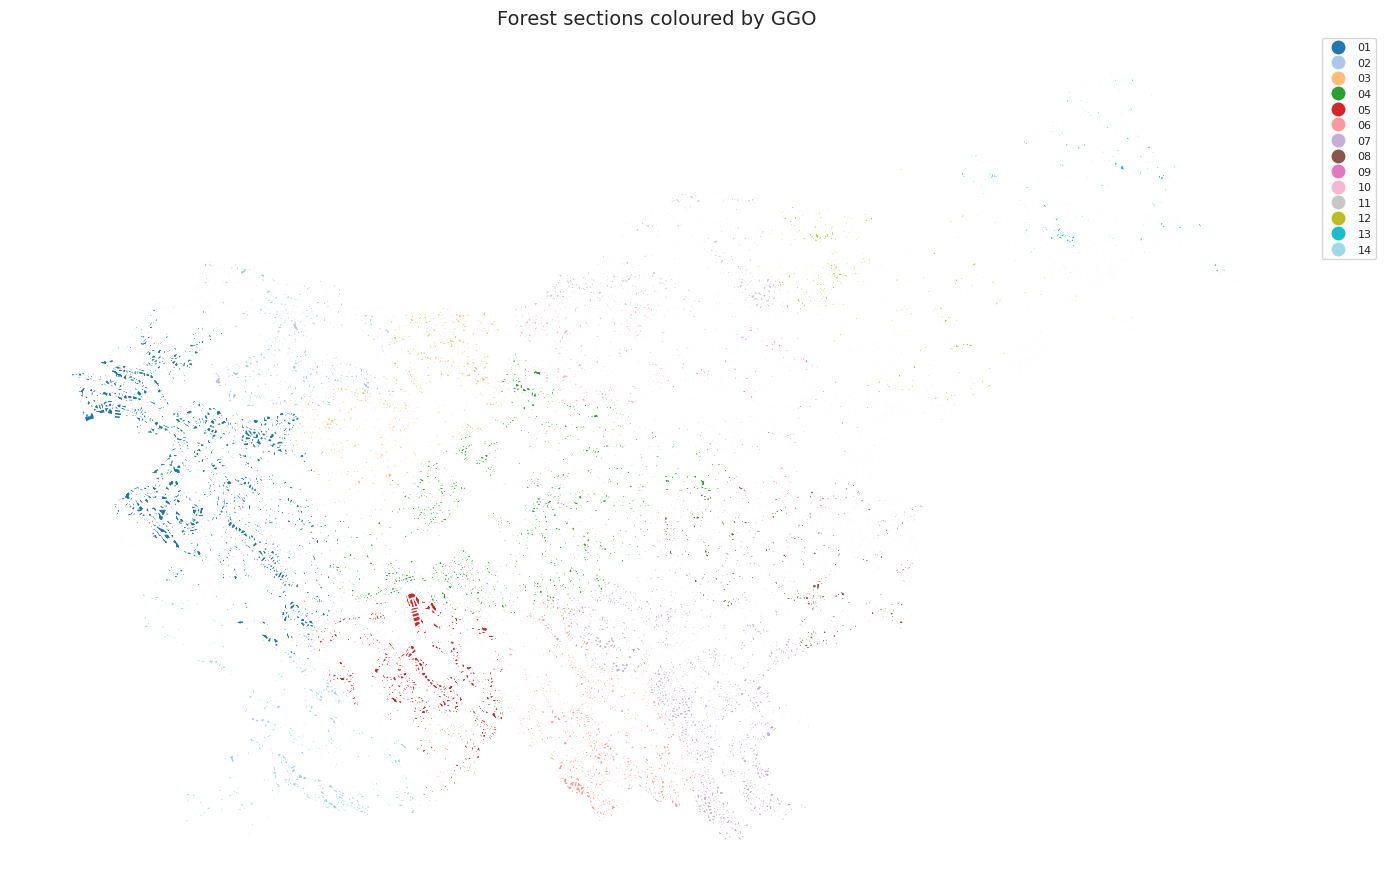

In [24]:
# Spatial map coloured by GGO
fig, ax = plt.subplots(figsize=(14, 10))
odseki.plot(column='ggo', ax=ax, legend=True, cmap='tab20',
            legend_kwds={'bbox_to_anchor': (1.01, 1), 'loc': 'upper left', 'fontsize': 8})
ax.set_title('Forest sections coloured by GGO', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

---
## 4. sestoji.gpkg — Forest Stands

In [26]:
sestoji = gpd.read_file(RAW / 'ZGS' / 'sestoji.gpkg')

print(f'Shape: {sestoji.shape}')
print(f'CRS:   {sestoji.crs}')
sestoji.drop(columns='geometry').head()

Shape: (350593, 45)
CRS:   EPSG:3794


,ggo,ggo_naziv,odsek,sestoj,povrsina,rfaza,rfaza_naziv,lzskdv11,lzskdv11_m,lzskdv21,lzskdv21_m,lzskdv30,lzskdv30_m,lzskdv34,lzskdv34_m,...,zasnova,zasnova_naziv,sklep,sklep_naziv,negovan,negovanost_naziv,pompov,pomzas,pomzas_naziv,lzigl,lzlst,lzsku,etigl,etlst,etsku
0,01,TOLMIN,01001A,A212,5.90,7,RAZNOMERNO (sk-gnz) ...,43.23,0.0,1.16,0.0,0.0,0.0,39.75,0.0,...,,Ni podatka,,Ni podatka,3,NENEGOVAN,0.0,0,NaN,796.0,150.0,946.0,0,0,0
1,01,TOLMIN,01001A,A213,16.92,7,RAZNOMERNO (sk-gnz) ...,32.32,0.0,1.91,0.0,0.0,0.0,47.85,0.0,...,,Ni podatka,,Ni podatka,3,NENEGOVAN,0.0,0,NaN,4561.0,996.0,5557.0,0,0,0
2,01,TOLMIN,01001A,A214,4.19,3,DEBELJAK ...,18.98,0.0,4.49,0.0,0.0,0.0,13.48,0.0,...,,Ni podatka,2,NORMALEN,3,NENEGOVAN,0.0,0,NaN,625.0,1066.0,1691.0,0,0,0
3,01,TOLMIN,01001B,A212,47.09,7,RAZNOMERNO (sk-gnz) ...,43.17,0.0,1.14,0.0,0.0,0.0,39.76,0.0,...,,Ni podatka,,Ni podatka,3,NENEGOVAN,0.0,0,NaN,6039.0,1145.0,7184.0,0,0,0
4,01,TOLMIN,01001B,A213,0.62,7,RAZNOMERNO (sk-gnz) ...,32.14,0.0,2.04,0.0,0.0,0.0,47.96,0.0,...,,Ni podatka,,Ni podatka,3,NENEGOVAN,0.0,0,NaN,161.0,35.0,196.0,0,0,0


In [27]:
sestoji.drop(columns='geometry').describe().T

,count,mean,std,min,25%,50%,75%,max
povrsina,350593.0,3.358462,5.253450,0.0,0.74,1.70,3.92,217.35
lzskdv11,350593.0,23.957587,31.472858,0.0,0.00,6.30,42.12,141.46
lzskdv11_m,350593.0,13.108306,26.465586,0.0,0.00,0.00,15.00,5700.00
lzskdv21,350593.0,4.357248,12.808798,0.0,0.00,0.00,0.00,126.92
lzskdv21_m,350593.0,2.340030,9.615255,0.0,0.00,0.00,0.00,400.00
lzskdv30,350593.0,5.907783,17.391400,0.0,0.00,0.00,0.70,187.36
lzskdv30_m,350593.0,0.467635,4.223519,0.0,0.00,0.00,0.00,418.18
lzskdv34,350593.0,0.951492,5.776083,0.0,0.00,0.00,0.00,102.50
lzskdv34_m,350593.0,0.180481,2.455026,0.0,0.00,0.00,0.00,100.00
lzskdv39,350593.0,0.372705,4.864375,0.0,0.00,0.00,0.00,100.00


In [28]:
print('Missing values (%):')
(sestoji.drop(columns='geometry').isnull().sum() / len(sestoji) * 100).round(1)[lambda s: s > 0]

Missing values (%):


pomzas_naziv    52.3
dtype: float64

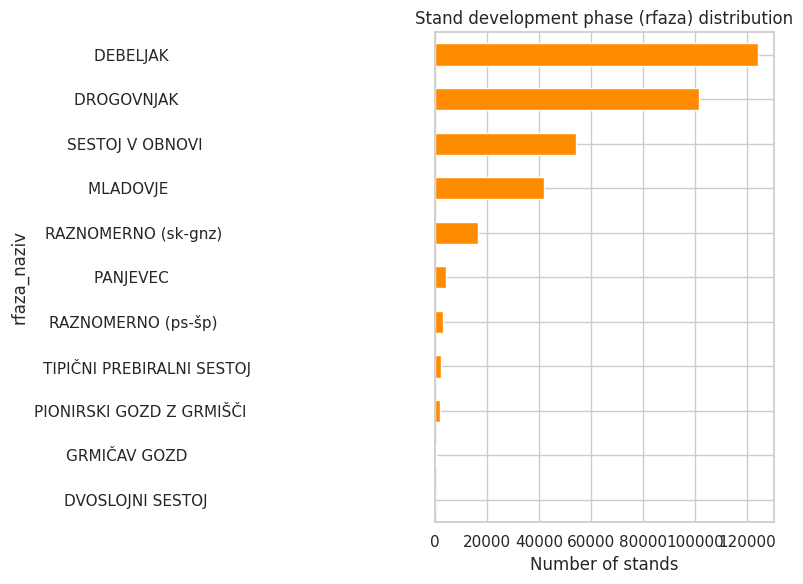

In [29]:
# Development phase (rfaza) distribution
sestoji['rfaza_naziv'].value_counts().sort_values().plot(
    kind='barh', figsize=(8, 6), color='darkorange',
    title='Stand development phase (rfaza) distribution'
)
plt.xlabel('Number of stands')
plt.tight_layout()
plt.show()

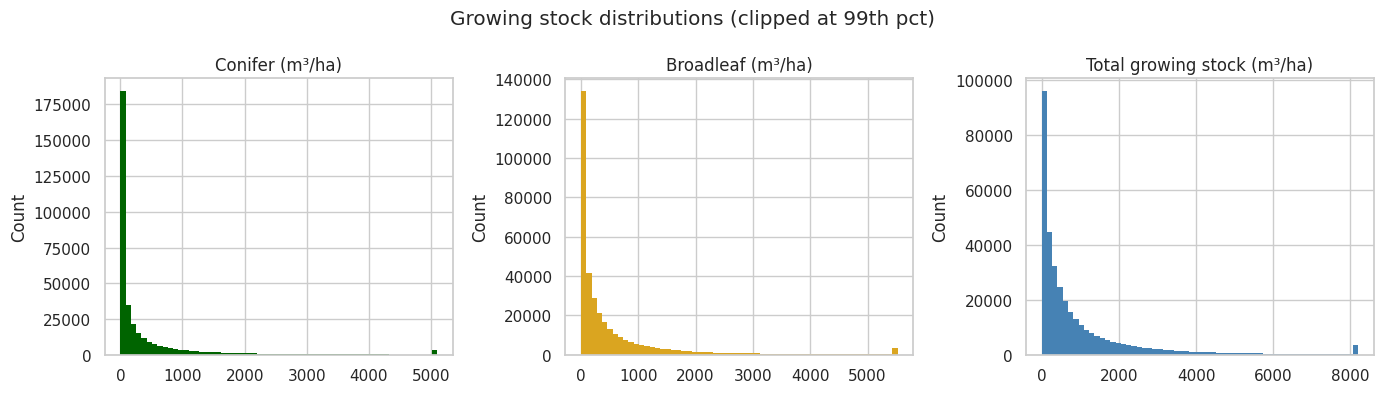

In [30]:
# Tree species composition: conifer vs broadleaf (lzskdv columns = basal area shares)
# lzigl = conifer growing stock (m³/ha), lzlst = broadleaf, lzsku = total
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, label, color in zip(
    axes,
    ['lzigl', 'lzlst', 'lzsku'],
    ['Conifer (m³/ha)', 'Broadleaf (m³/ha)', 'Total growing stock (m³/ha)'],
    ['darkgreen', 'goldenrod', 'steelblue']
):
    sestoji[col].clip(upper=sestoji[col].quantile(0.99)).hist(
        bins=60, ax=ax, color=color, edgecolor='none'
    )
    ax.set_title(label)
    ax.set_ylabel('Count')
plt.suptitle('Growing stock distributions (clipped at 99th pct)')
plt.tight_layout()
plt.show()

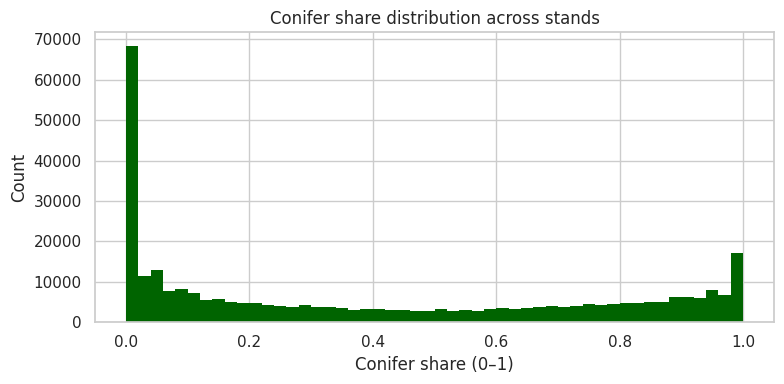

In [31]:
# Conifer share per stand
sestoji['del_iglavcev'] = sestoji['lzigl'] / sestoji['lzsku'].replace(0, float('nan'))
fig, ax = plt.subplots(figsize=(8, 4))
sestoji['del_iglavcev'].dropna().hist(bins=50, ax=ax, color='darkgreen', edgecolor='none')
ax.set_xlabel('Conifer share (0–1)')
ax.set_ylabel('Count')
ax.set_title('Conifer share distribution across stands')
plt.tight_layout()
plt.show()

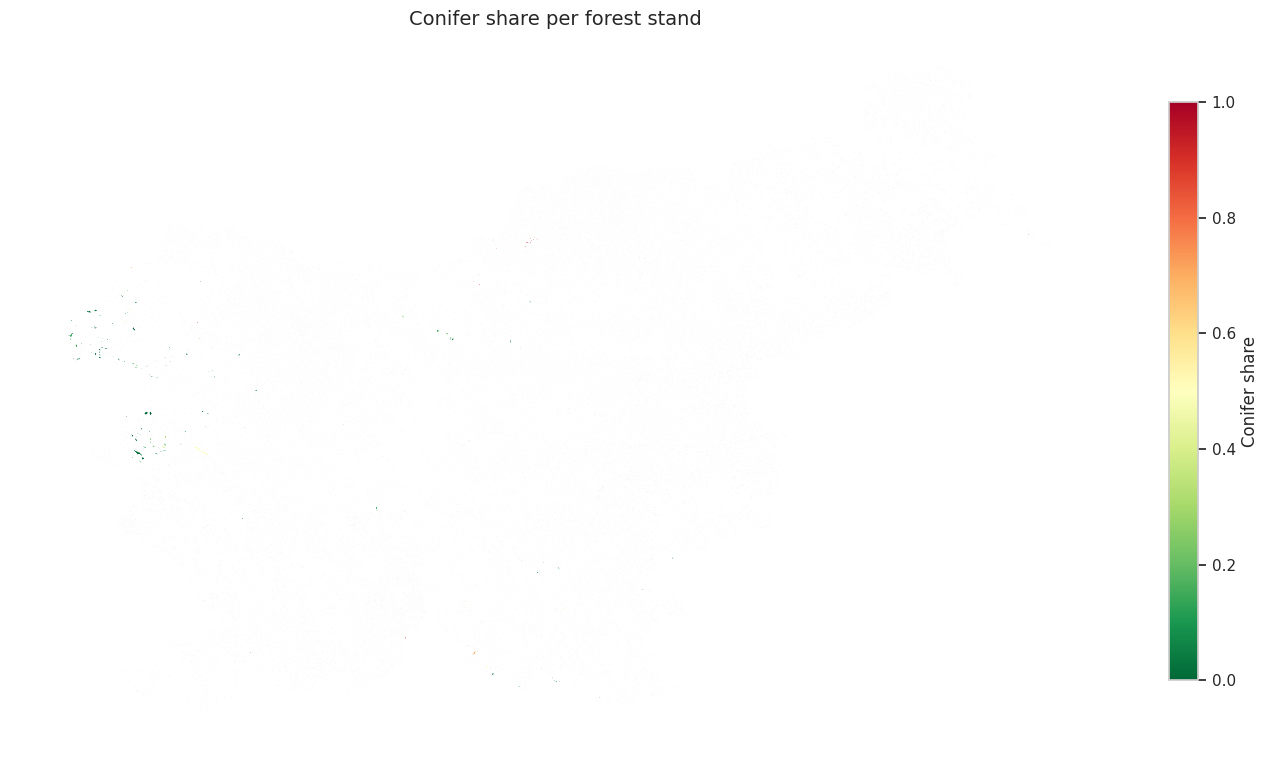

In [32]:
# Spatial map coloured by conifer share
fig, ax = plt.subplots(figsize=(14, 10))
sestoji.plot(column='del_iglavcev', ax=ax, cmap='RdYlGn_r',
             legend=True, missing_kwds={'color': 'lightgrey'},
             legend_kwds={'label': 'Conifer share', 'shrink': 0.6})
ax.set_title('Conifer share per forest stand', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

---
## 5. Quick Cross-Dataset Summary

In [33]:
summary = pd.DataFrame([
    {'dataset': 'posek.csv',           'rows': len(posek),   'cols': posek.shape[1],   'spatial': False},
    {'dataset': 'vreme.csv',           'rows': len(vreme),   'cols': vreme.shape[1],   'spatial': False},
    {'dataset': 'odseki_gozdno.gpkg',  'rows': len(odseki),  'cols': odseki.shape[1],  'spatial': True},
    {'dataset': 'sestoji.gpkg',        'rows': len(sestoji), 'cols': sestoji.shape[1], 'spatial': True},
]).set_index('dataset')

summary

,rows,cols,spatial
dataset,,,
posek.csv,450064,9,False
vreme.csv,1556514,12,False
odseki_gozdno.gpkg,53254,56,True
sestoji.gpkg,350593,46,True


In [34]:
# Shared join key: odsek — check overlap between posek and odseki_gozdno
posek_ids   = set(posek['odsek'].dropna().unique())
odseki_ids  = set(odseki['odsek'].dropna().unique())
sestoji_ids = set(sestoji['odsek'].dropna().unique())

print(f'posek odsek count:          {len(posek_ids):,}')
print(f'odseki_gozdno odsek count:  {len(odseki_ids):,}')
print(f'sestoji odsek count:        {len(sestoji_ids):,}')
print()
print(f'posek ∩ odseki_gozdno:      {len(posek_ids & odseki_ids):,}')
print(f'posek ∩ sestoji:            {len(posek_ids & sestoji_ids):,}')
print(f'odseki_gozdno ∩ sestoji:    {len(odseki_ids & sestoji_ids):,}')

posek odsek count:          25,691
odseki_gozdno odsek count:  35,688
sestoji odsek count:        35,688

posek ∩ odseki_gozdno:      25,668
posek ∩ sestoji:            25,668
odseki_gozdno ∩ sestoji:    35,688
